In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv('/kaggle/input/datasets/steam2312/intdataset/Project4_Ag_Prediction of Agriculture Crop Production In India/produce.csv')
df2 = pd.read_csv('/kaggle/input/datasets/steam2312/intdataset/Project4_Ag_Prediction of Agriculture Crop Production In India/datafile (2).csv')
df3 = pd.read_csv('/kaggle/input/datasets/steam2312/intdataset/Project4_Ag_Prediction of Agriculture Crop Production In India/datafile (3).csv')

print(df1.head())
print(df2.head())
print(df3.head())

                                      Particulars  \
0              Agricultural Production Foodgrains   
1       Agricultural Production Foodgrains Kharif   
2         Agricultural Production Foodgrains Rabi   
3         Agricultural Production Foodgrains Rice   
4  Agricultural Production Foodgrains Rice Kharif   

                         Frequency    Unit   3-1993   3-1994   3-1995  \
0  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   
1  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   
2  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   
3  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   
4  Annual, Ending mar Of Each Year  Ton mn      NaN      NaN      NaN   

    3-1996   3-1997   3-1998   3-1999  ...     3-2005    3-2006     3-2007  \
0      NaN      NaN      NaN      NaN  ...  198.36282  208.6016  217.28212   
1      NaN      NaN      NaN      NaN  ...  103.30942  109.8734  110.57622   
2      N

In [3]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['Particulars', 'Frequency', 'Unit', ' 3-1993', ' 3-1994', ' 3-1995',
       ' 3-1996', ' 3-1997', ' 3-1998', ' 3-1999', ' 3-2000', ' 3-2001',
       ' 3-2002', ' 3-2003', ' 3-2004', ' 3-2005', ' 3-2006', ' 3-2007',
       ' 3-2008', ' 3-2009', ' 3-2010', ' 3-2011', ' 3-2012', ' 3-2013',
       ' 3-2014'],
      dtype='object')
Index(['Crop             ', 'Production 2006-07', 'Production 2007-08',
       'Production 2008-09', 'Production 2009-10', 'Production 2010-11',
       'Area 2006-07', 'Area 2007-08', 'Area 2008-09', 'Area 2009-10',
       'Area 2010-11', 'Yield 2006-07', 'Yield 2007-08', 'Yield 2008-09',
       'Yield 2009-10', 'Yield 2010-11'],
      dtype='object')
Index(['Crop', 'Variety', 'Season/ duration in days', 'Recommended Zone',
       'Unnamed: 4'],
      dtype='object')


In [4]:
df2.head()

,Crop,Production 2006-07,Production 2007-08,Production 2008-09,Production 2009-10,Production 2010-11,Area 2006-07,Area 2007-08,Area 2008-09,Area 2009-10,Area 2010-11,Yield 2006-07,Yield 2007-08,Yield 2008-09,Yield 2009-10,Yield 2010-11
0,Total Foodgrains,158.8,168.6,171.3,159.4,178.9,128.5,128.8,127.6,126.0,131.7,123.6,130.9,134.3,126.5,135.9
1,Rice,200.8,207.9,213.3,191.6,206.4,168.5,168.9,175.1,161.2,164.8,119.2,123.1,121.8,118.9,125.2
2,Wheat,131.6,136.4,140.1,140.3,150.8,115.0,115.2,114.0,116.9,119.5,114.4,118.4,122.8,120.0,126.3
3,Jowar,124.3,137.8,126.0,116.5,121.8,120.7,110.6,107.3,111.0,105.2,103.0,124.6,117.4,105.0,115.8
4,Bajra,136.4,161.5,143.9,105.4,167.9,94.5,95.1,87.0,88.5,95.6,144.3,169.7,165.4,119.0,175.8


In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                55 non-null     object 
 1   Production 2006-07  55 non-null     float64
 2   Production 2007-08  55 non-null     float64
 3   Production 2008-09  55 non-null     float64
 4   Production 2009-10  55 non-null     float64
 5   Production 2010-11  55 non-null     float64
 6   Area 2006-07        55 non-null     float64
 7   Area 2007-08        55 non-null     float64
 8   Area 2008-09        55 non-null     float64
 9   Area 2009-10        55 non-null     float64
 10  Area 2010-11        55 non-null     float64
 11  Yield 2006-07       55 non-null     float64
 12  Yield 2007-08       55 non-null     float64
 13  Yield 2008-09       55 non-null     float64
 14  Yield 2009-10       55 non-null     float64
 15  Yield 2010-11       55 non-null     float64
dtypes: float64

In [6]:
import pandas as pd

years = ['2006-07', '2007-08', '2008-09', '2009-10', '2010-11']

rows = []

for _, row in df2.iterrows():
    for year in years:
        rows.append({
            'Crop': row['Crop             '].strip(),
            'Year': year,
            'Production': row[f'Production {year}'],
            'Area': row[f'Area {year}'],
            'Yield': row[f'Yield {year}']
        })

ml_df = pd.DataFrame(rows)

print(ml_df.shape)
ml_df.head()

(275, 5)


,Crop,Year,Production,Area,Yield
0,Total Foodgrains,2006-07,158.8,128.5,123.6
1,Total Foodgrains,2007-08,168.6,128.8,130.9
2,Total Foodgrains,2008-09,171.3,127.6,134.3
3,Total Foodgrains,2009-10,159.4,126.0,126.5
4,Total Foodgrains,2010-11,178.9,131.7,135.9


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

ml_df['Crop'] = le.fit_transform(ml_df['Crop'])

In [12]:
X = ml_df[['Crop', 'Production', 'Area']]
y = ml_df['Yield']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

MAE : 4.6312909090909224
MSE : 46.512916709091016
R2 Score : 0.9609469232584257


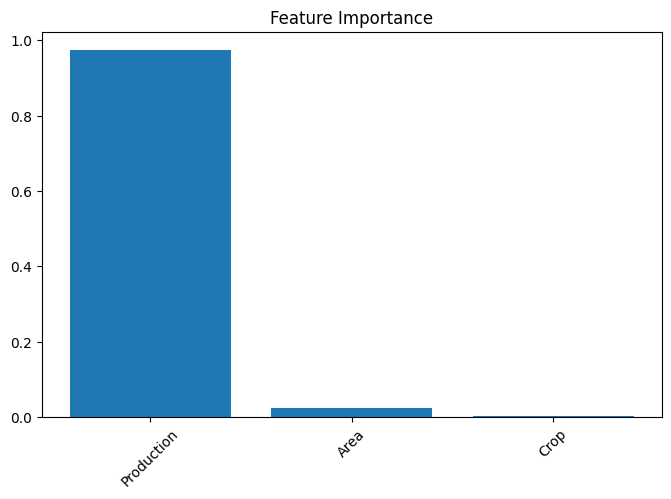

In [20]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(importance['Feature'], importance['Importance'])
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()

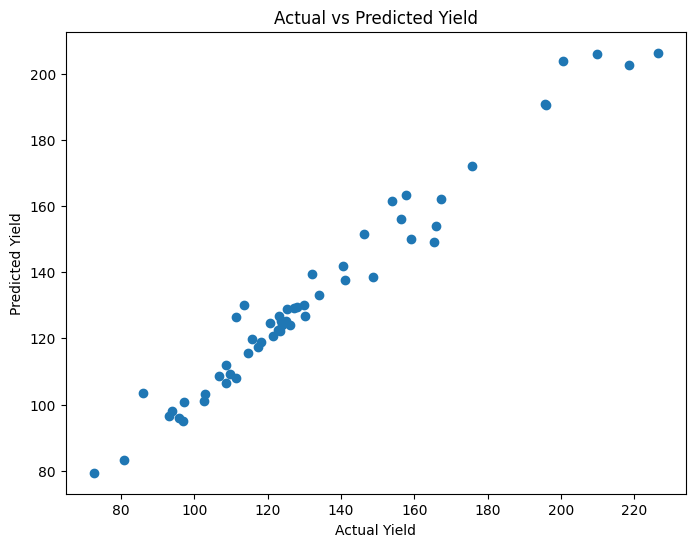

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.show()

In [22]:
print("R2 Score:", r2)

R2 Score: 0.9609469232584257


In [23]:
df1.head()

,Particulars,Frequency,Unit,3-1993,3-1994,3-1995,3-1996,3-1997,3-1998,3-1999,...,3-2005,3-2006,3-2007,3-2008,3-2009,3-2010,3-2011,3-2012,3-2013,3-2014
0,Agricultural Production Foodgrains,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,198.36282,208.6016,217.28212,230.77504,234.466177,218.107372,244.491809,259.286253,257.13,264.3806
1,Agricultural Production Foodgrains Kharif,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,103.30942,109.8734,110.57622,120.95724,118.138577,103.954032,120.853191,131.274812,128.07,129.3686
2,Agricultural Production Foodgrains Rabi,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95.05340,98.7282,106.70590,109.81780,116.327600,114.153340,123.638618,128.011441,129.06,135.0120
3,Agricultural Production Foodgrains Rice,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,83.13170,91.7934,93.35530,96.69290,99.182500,89.092901,95.979819,105.301100,105.24,106.2872
4,Agricultural Production Foodgrains Rice Kharif,"Annual, Ending mar Of Each Year",Ton mn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,72.23000,78.2719,80.17080,82.65940,84.908200,75.916510,80.651241,92.780700,92.37,92.0093


In [24]:
df1['Particulars']

0                     Agricultural Production Foodgrains
1              Agricultural Production Foodgrains Kharif
2                Agricultural Production Foodgrains Rabi
3                Agricultural Production Foodgrains Rice
4         Agricultural Production Foodgrains Rice Kharif
                             ...                        
424    Agricultural Production Foodgrains Coarse Cere...
425    Agricultural Production Foodgrains Coarse Cere...
426    Agricultural Production Foodgrains Coarse Cere...
427    Agricultural Production Foodgrains Coarse Cere...
428    Agricultural Production Foodgrains Coarse Cere...
Name: Particulars, Length: 429, dtype: object

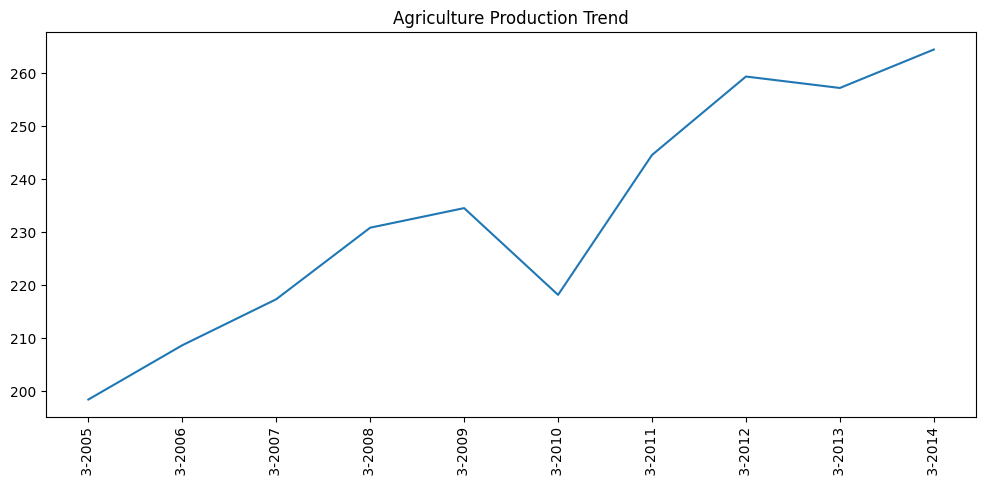

In [25]:
years = [' 3-1993',' 3-1994',' 3-1995',' 3-1996',' 3-1997',
         ' 3-1998',' 3-1999',' 3-2000',' 3-2001',' 3-2002',
         ' 3-2003',' 3-2004',' 3-2005',' 3-2006',' 3-2007',
         ' 3-2008',' 3-2009',' 3-2010',' 3-2011',' 3-2012',
         ' 3-2013',' 3-2014']

row = df1.iloc[0]

values = row[years]

plt.figure(figsize=(12,5))
plt.plot(years, values)
plt.xticks(rotation=90)
plt.title("Agriculture Production Trend")
plt.show()

In [26]:
df3.head()

,Crop,Variety,Season/ duration in days,Recommended Zone,Unnamed: 4
0,Paddy,Chinsurah Rice (IET 19140),Medium,"Andhra Pradesh, Tamil Nadu, Gujarat, Orissa, a...",NaN
1,Paddy,(CNI 383-5-11),NaN,NaN,NaN
2,Paddy,IGKVR-1 (IET 19569),Mid-early,"Chhattisgarh, Madhya Pradesh and Orissa under ...",NaN
3,Paddy,IGKVR-2 (IET 19795),Medium,"Chhattisgarh, Bihar and Orissa under both irr...",NaN
4,Paddy,CR Dhan 401 (REETA),145-150,"Orissa, West Bengal, Tamil Nadu and Andhra Pra...",NaN


In [27]:
print(df3['Crop'].nunique())

29


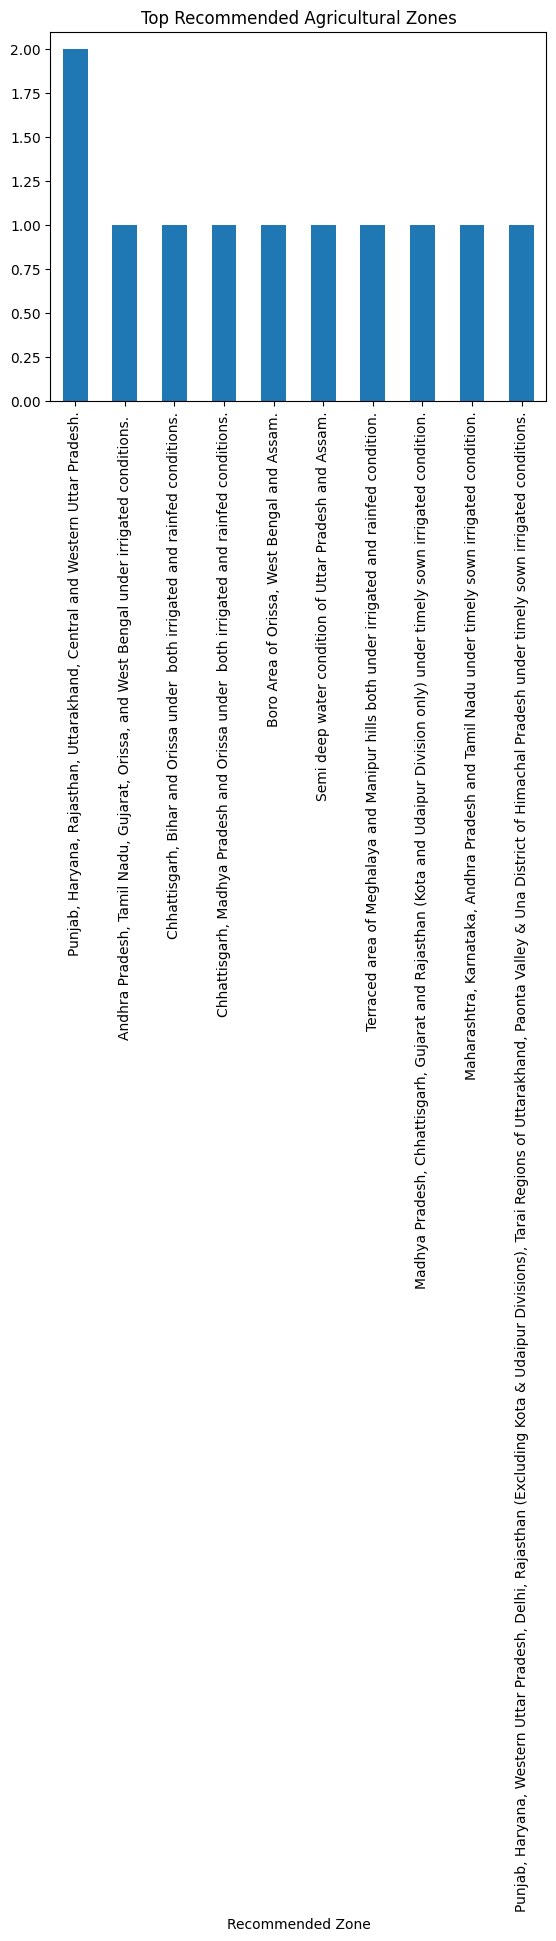

In [28]:
df3['Recommended Zone'].value_counts().head(10).plot(kind='bar')

plt.title("Top Recommended Agricultural Zones")

plt.show()

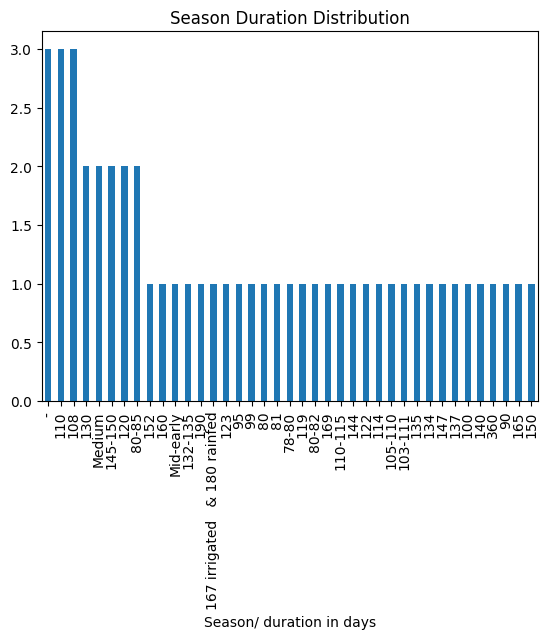

In [29]:
df3['Season/ duration in days'].value_counts().plot(kind='bar')

plt.title("Season Duration Distribution")

plt.show()

In [30]:
sample = [[10, 150, 120]]

prediction = model.predict(sample)

print("Predicted Yield:", prediction[0])

Predicted Yield: 122.4900000000001


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [31]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(20)

,Actual,Predicted
30,93.2,96.660
139,80.8,83.186
195,102.6,101.139
126,132.1,139.354
215,108.8,111.820
233,125.0,125.341
250,106.9,108.642
202,195.8,190.444
253,108.8,106.621
142,146.3,151.493
